> **⚠️ SUPERSEDED (2026-07-08).** This raw / single-tail view keeps the frequency / founder-projection confound and is **not** evidence of SV climate purging. The de-trended `s_distribution_by_site.ipynb` is authoritative, and after the full-panel Kf_w / `--unit chrom` regeneration the SV excess-vs-baseline is null there (median +0.0011, 15/31 sites, sign test n.s.).

# SV vs SNP selection difference against an independent axis (climate)

The shift function compared the two *s-distributions* (selection on both axes). Here we put the
**frequency-matched SV−SNP selection difference on y** and an **independent variable — site mean
annual temperature (bio1) — on x**. One point per site. SNP (and indel) are resampled to the SV p₀
distribution first, so the difference is not a rarity artifact. No MAF filter (all reachable
variants).

- **y = mean s(SV) − mean s(matched SNP)** (left) and **10th-percentile difference** (right, the
  purged tail). Below 0 = SVs more purged than same-frequency SNPs at that site.
- **x = bio1** (independent of selection). A downward trend ⇒ SV purging strengthens at hot sites.

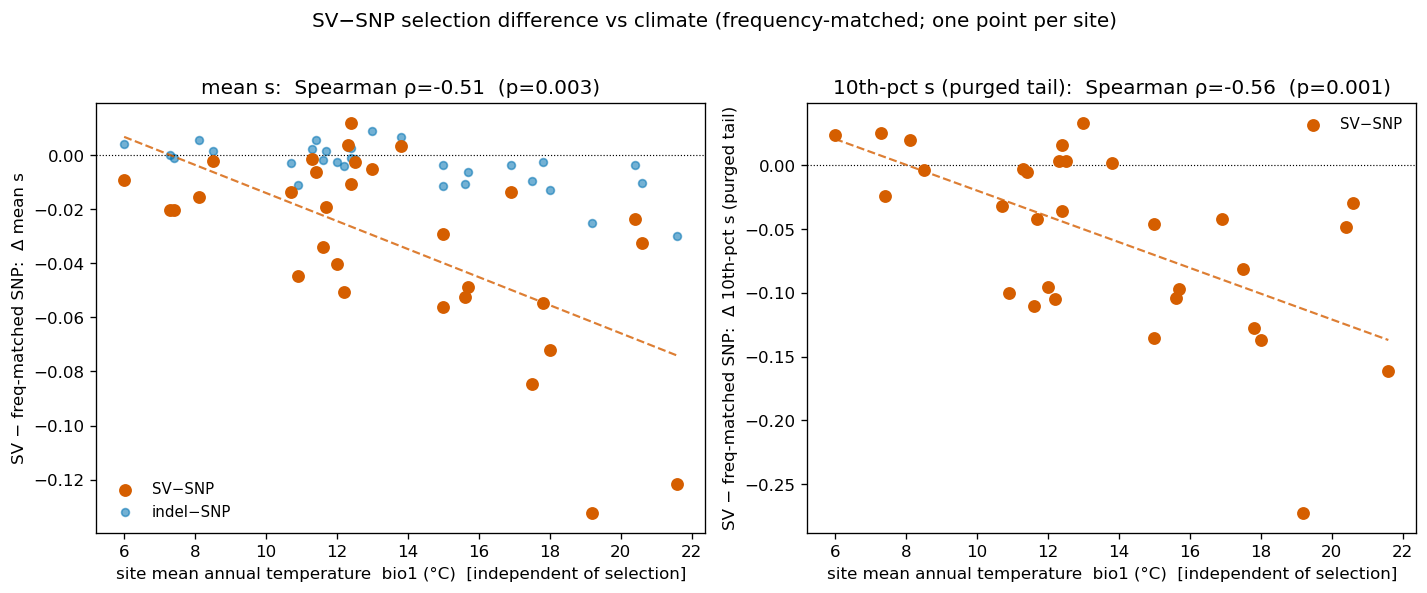

purged-tail (10th pct) SV<SNP at hot sites (bio1>=15): 12/12
mean-s difference: median across sites -0.0204; indel-SNP median -0.0024 (~0)


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':120,'font.size':10})
G = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
npz = np.load(f"{G}/s_dist_by_stratum.npz")
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv")
NBIN, NDRAW = 25, 20000; rng = np.random.default_rng(0)

def match_to(target_p0, src_s, src_p0):
    edges = np.quantile(np.concatenate([target_p0, src_p0]), np.linspace(0,1,NBIN+1)); edges[-1]+=1e-9
    tb = np.digitize(target_p0, edges[1:-1]); sb = np.digitize(src_p0, edges[1:-1])
    props = np.array([(tb==b).mean() for b in range(NBIN)]); out=[]
    for b in range(NBIN):
        k=int(round(props[b]*NDRAW)); pool=src_s[sb==b]
        if k>0 and pool.size>0: out.append(rng.choice(pool,k,replace=True))
    return np.concatenate(out)

rows=[]
for s in meta.site:
    sv=npz[f"{s}_s_SV"]; p_sv=npz[f"{s}_p0_SV"]
    msn=match_to(p_sv, npz[f"{s}_s_SNP"], npz[f"{s}_p0_SNP"])
    mind=match_to(p_sv, npz[f"{s}_s_indel"], npz[f"{s}_p0_indel"])
    rows.append(dict(site=s, bio1=meta[meta.site==s].bio1.iloc[0],
        d_mean=sv.mean()-msn.mean(), d_p10=np.quantile(sv,.10)-np.quantile(msn,.10),
        ind_mean=mind.mean()-msn.mean()))
d=pd.DataFrame(rows)

fig, ax = plt.subplots(1,2, figsize=(12,4.8))
for a,(col,lab) in zip(ax, [("d_mean","mean s"),("d_p10","10th-pct s (purged tail)")]):
    a.axhline(0,color="k",lw=0.7,ls=":")
    a.scatter(d.bio1, d[col], c="#D55E00", s=45, zorder=3, label="SV−SNP")
    if col=="d_mean":
        a.scatter(d.bio1, d.ind_mean, c="#0072B2", s=22, alpha=.55, label="indel−SNP")
    r=stats.spearmanr(d.bio1, d[col])
    b,a0=np.polyfit(d.bio1, d[col],1); xs=np.array([d.bio1.min(),d.bio1.max()])
    a.plot(xs, a0+b*xs, color="#D55E00", lw=1.3, ls="--", alpha=.8)
    a.set_xlabel("site mean annual temperature  bio1 (°C)  [independent of selection]")
    a.set_ylabel(f"SV − freq-matched SNP:  Δ {lab}")
    a.set_title(f"{lab}:  Spearman ρ={r.statistic:+.2f}  (p={r.pvalue:.3f})")
    a.legend(frameon=False, fontsize=9)
fig.suptitle("SV−SNP selection difference vs climate (frequency-matched; one point per site)", y=1.02)
fig.tight_layout(); fig.savefig(f"{G}/s_vs_climate.png", dpi=130, bbox_inches="tight"); plt.show()
nneg_hot=int(((d.bio1>=15)&(d.d_p10<0)).sum()); nhot=int((d.bio1>=15).sum())
print(f"purged-tail (10th pct) SV<SNP at hot sites (bio1>=15): {nneg_hot}/{nhot}")
print(f"mean-s difference: median across sites {d.d_mean.median():+.4f}; "
      f"indel-SNP median {d.ind_mean.median():+.4f} (~0)")


### Reading
- **indel−SNP (blue) sits on 0 at all temperatures** — indels are like SNPs regardless of climate.
- **SV−SNP (orange) trends downward with temperature** — the hotter the site, the more SVs are
  purged relative to same-frequency SNPs, especially in the purged tail (right panel). Now selection
  is on y and an *independent* variable (climate) is on x, so this is a genuine relationship, not a
  selection-vs-selection tautology.
- Caveat unchanged: insertion-polarized + founder-projection (can't prove SV-specific vs haplotype
  hitchhiking).